# Telemarketing data analysis

##### En este jupyter notebook resolveremos el caso 2 propuesto en la asignatura Data Exploration del executive máster of business analytics de ESADE.
##### El objetivo es optimizar la estrategia de negocio y aumentar la efectividad del plan de marketing. Para ello se analizan los datos de la última campaña de telemarketing para buscar respuesta a las siguientes preguntas de negocio:
#####   1 - Who the bank is targeting with its campaigns? 
#####   2 - Argue if the bank telemarketing strategy is appropriate. 
#####   3 - Profile the customers with higher likelihood of conversion and compare it with current bank targeting.

## 1.- Importación de librerías

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df_raw = pd.read_csv(r"C:\Users\emc\Desktop\Diana\ESADE\Data Exploration\Clase 4\bank-full_clean.csv")

In [6]:
df = df_raw

## 2.- EDA

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40841 entries, 0 to 40840
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              40841 non-null  int64  
 1   job              40841 non-null  object 
 2   marital          40841 non-null  object 
 3   education        40841 non-null  object 
 4   default          40841 non-null  object 
 5   balance          40841 non-null  int64  
 6   housing          40841 non-null  object 
 7   loan             40841 non-null  object 
 8   day              40841 non-null  int64  
 9   month            40841 non-null  object 
 10  duration         40841 non-null  float64
 11  campaign         40841 non-null  int64  
 12  pdays            40841 non-null  int64  
 13  previous         40841 non-null  int64  
 14  poutcome         40841 non-null  object 
 15  response         40841 non-null  object 
 16  response_binary  40841 non-null  int64  
 17  month_int   

C:\Users\emc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='pdays', ylabel='Count'>

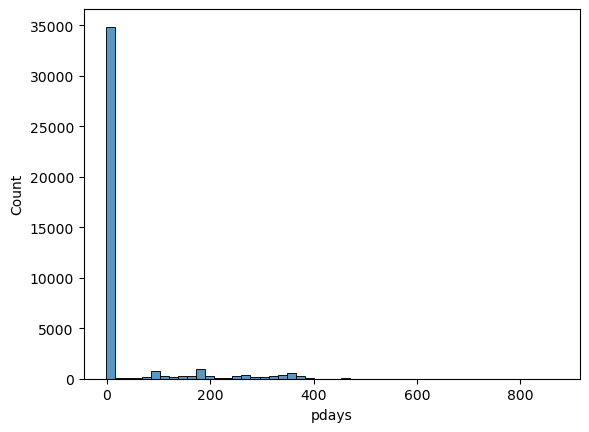

In [10]:
# Qué significa -1???
sns.histplot(df['pdays'], bins = 50)

In [11]:
# The number of contacts performed during this campaign for the individual (numeric).
print(df['campaign'].sort_values().value_counts())
# Por qué hay gente a quien se llamó 58 veces?!

campaign
1     15788
2     11306
3      4954
4      3241
5      1606
6      1169
7       649
8       489
9       288
10      248
11      180
12      145
13      123
14       84
15       82
16       75
17       64
18       45
19       43
20       39
21       34
23       20
24       20
22       20
25       19
28       16
29       13
26       12
31       10
27        9
32        9
30        8
33        6
36        4
34        4
35        3
38        3
41        2
43        2
50        2
37        1
39        1
44        1
46        1
51        1
55        1
58        1
Name: count, dtype: int64


C:\Users\emc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='duration', ylabel='Count'>

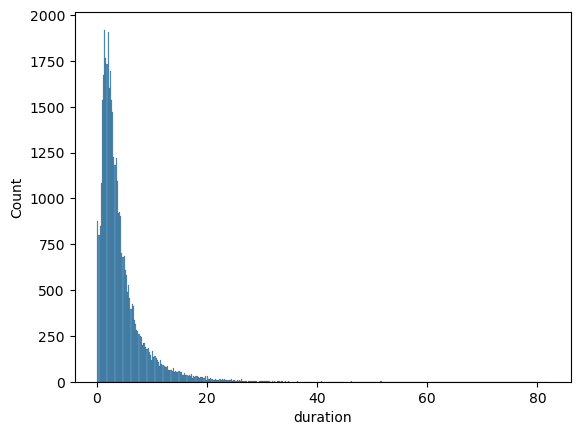

In [12]:
sns.histplot(df['duration'])

In [13]:
print(df['duration'].value_counts())

duration
1.50     168
2.07     167
1.48     166
1.73     166
2.03     163
        ... 
18.55      1
28.02      1
23.48      1
25.60      1
25.93      1
Name: count, Length: 1539, dtype: int64


In [14]:
print(df['month'].value_counts()) 

month
may    12496
jul     6520
aug     5877
jun     4853
nov     3483
apr     2529
feb     2258
jan     1183
oct      605
sep      457
mar      407
dec      173
Name: count, dtype: int64


In [15]:
print(df['loan'].value_counts()) 

loan
no     34042
yes     6799
Name: count, dtype: int64


In [16]:
print(df['housing'].value_counts()) #Crédito hipotecario

housing
yes    22820
no     18021
Name: count, dtype: int64


In [17]:
print(df['balance'].value_counts()) #cantidad de dinero del cliente en el banco

balance
0       3272
1        183
2        149
4        131
3        125
        ... 
3390       1
9881       1
2534       1
2113       1
9299       1
Name: count, Length: 6350, dtype: int64


In [18]:
print(df['default'].value_counts()) #Deudor de pagos de tarjeta de crédito

default
no     40078
yes      763
Name: count, dtype: int64


In [19]:
print(df['education'].value_counts())

education
secondary    21933
tertiary     12380
primary       6528
Name: count, dtype: int64


In [20]:
print(df['marital'].value_counts())

marital
married     24641
single      11443
divorced     4757
Name: count, dtype: int64


In [22]:
print(df['job'].value_counts())
df['job'] = [x.replace('.','') for x in df['job']]

job
blue-collar      8805
management       8565
technician       6954
admin            4705
services         3801
retired          2020
self-employed    1443
entrepreneur     1340
unemployed       1212
housemaid        1149
student           689
other             158
Name: count, dtype: int64


In [23]:
len(df)

40841

In [24]:
print(df.groupby('response')['poutcome'].value_counts(normalize=True))
print(df.groupby('response')['poutcome'].value_counts(normalize=False))

response  poutcome
no        unknown     0.873930
          failure     0.112397
          success     0.013673
yes       unknown     0.682044
          success     0.193145
          failure     0.124811
Name: proportion, dtype: float64
response  poutcome
no        unknown     31638
          failure      4069
          success       495
yes       unknown      3164
          success       896
          failure       579
Name: count, dtype: int64


In [ ]:
print(df['response'].value_counts(normalize=True))

Tasa de conversión de la campaña: 11,35%

response: Clasificación binaria -> Si es "yes" es porque accedió a la oferta y contrató el producto ofrecido. Si es "no", rechazó la oferta
poutcome: Clasificación multiclase -> Si es "success" es porque en la campaña anterior, accedió a la oferta y contrató el producto ofrecido. Si es "failure" es que rechazó la oferta y si es "unknown" es que no fué contactado para la oferta en esa la campaña anterior.

-- Análisis de los pares response&poutcome
(77.47%) Response NO, Poutcome UNKNOWN -> Prospectos nuevos que no aceptaron la oferta.
(9.96%) Response NO, Poutcome FAILURE -> No compró antes y no compró ahora. Quienes son?
(1.21%) Response NO, Poutcome SUCCESS -> Compró antes y no compró ahora. En qué fallamos?
(7.75%) Response YES, Poutcome UNKNOWN -> Prospectos nuevos que aceptaron la oferta. Que hicimos bien?
(2.19%) Response YES, Poutcome FAILURE -> No contrató antes y ahora sí contrata. Qué cambió?
(1.42%) Response YES, Poutcome SUCCESS -> Contrató antes y ahora también. Clientes gold



## 3.- First question: Who the bank is targeting with its campaigns? 

Interpretación de la pregunta: La base de datos de la que disponemos contiene prospectos que se han intentado contactar para esta campaña, por lo cual estos representan al público objetivo de la empresa. Analizar demográficamente este público responde esta primera interrogante.

In [25]:
columnas_sociodemograficas = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing','loan']

In [37]:
(df["pdays"] == -1).mean() * 100  # Porcentaje de clientes "nuevos en la campaña"

85.20114590729904

In [40]:
# Un 85% de los clientes contactados no habían sido contactados en campañas anteriores, con lo cual, 
#el banco muestra una estrategia de intentar contactar con clientes nuevos

In [50]:
df["contacted_before"] = df["contacted_before"].astype(str)

In [46]:
# Análisis de ocupaciones contactadas

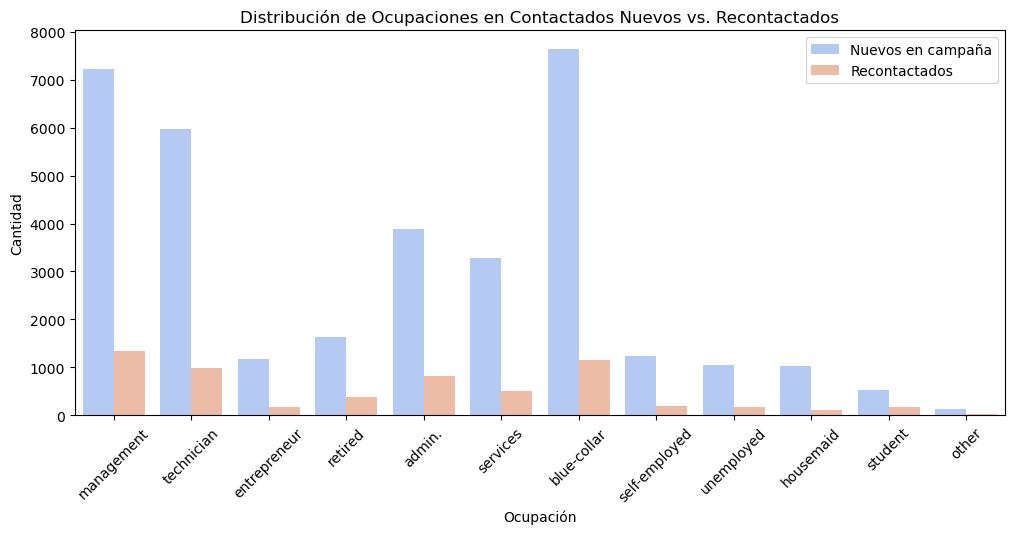

In [60]:
plt.figure(figsize=(12, 5))
sns.countplot(x="job", hue="contacted_before", data=df, palette="coolwarm")
plt.title("Distribución de Ocupaciones en Contactados Nuevos vs. Recontactados")
plt.xlabel("Ocupación")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.legend(["Nuevos en campaña", "Recontactados"])
plt.show()

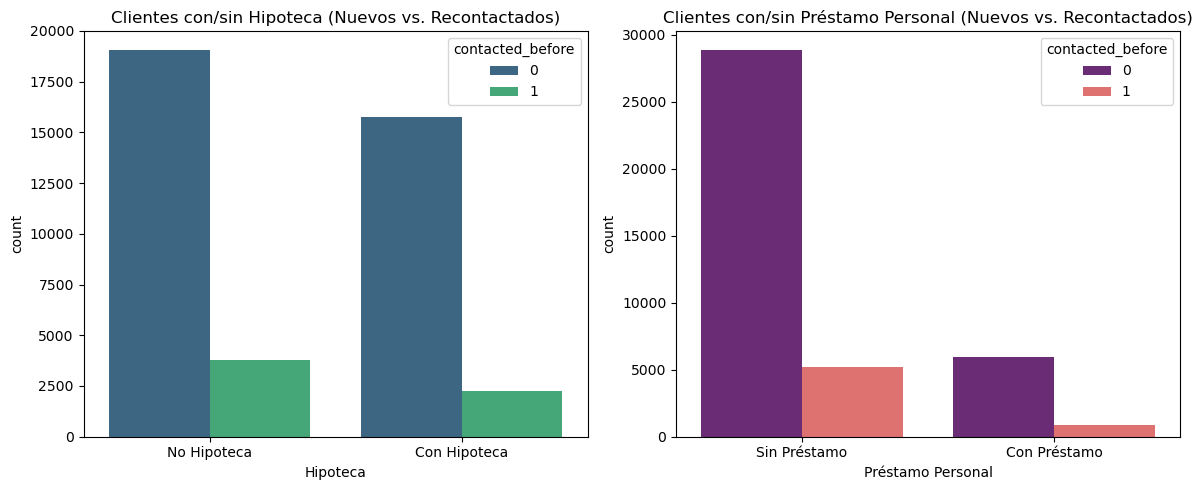

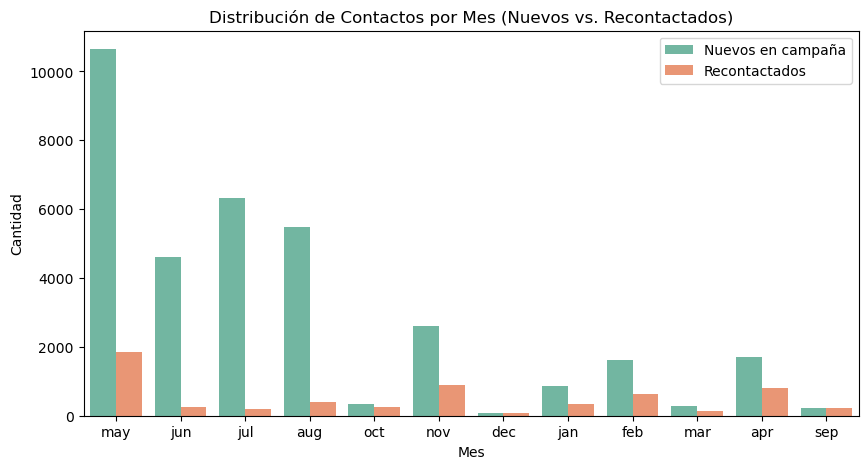

In [59]:
#  Análisis de clientes con/sin hipoteca y préstamo ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Hipoteca
sns.countplot(x="housing", hue="contacted_before", data=df, palette="viridis", ax=axes[0])
axes[0].set_title("Clientes con/sin Hipoteca (Nuevos vs. Recontactados)")
axes[0].set_xticklabels(["No Hipoteca", "Con Hipoteca"])
axes[0].set_xlabel("Hipoteca")

# Préstamo Personal
sns.countplot(x="loan", hue="contacted_before", data=df, palette="magma", ax=axes[1])
axes[1].set_title("Clientes con/sin Préstamo Personal (Nuevos vs. Recontactados)")
axes[1].set_xticklabels(["Sin Préstamo", "Con Préstamo"])
axes[1].set_xlabel("Préstamo Personal")

plt.tight_layout()
plt.show()
# Estos gráficos comparan la cantidad de clientes nuevos y recontactados según si tienen hipoteca o préstamos personales.

# Análisis de distribución de contactos por mes ---
plt.figure(figsize=(10, 5))
sns.countplot(x="month", hue="contacted_before", data=df, palette="Set2")
plt.title("Distribución de Contactos por Mes (Nuevos vs. Recontactados)")
plt.xlabel("Mes")
plt.ylabel("Cantidad")
plt.legend(["Nuevos en campaña", "Recontactados"])
plt.show()
# Este gráfico muestra cuántos clientes han sido contactados en cada mes, diferenciando entre nuevos y recontactados.

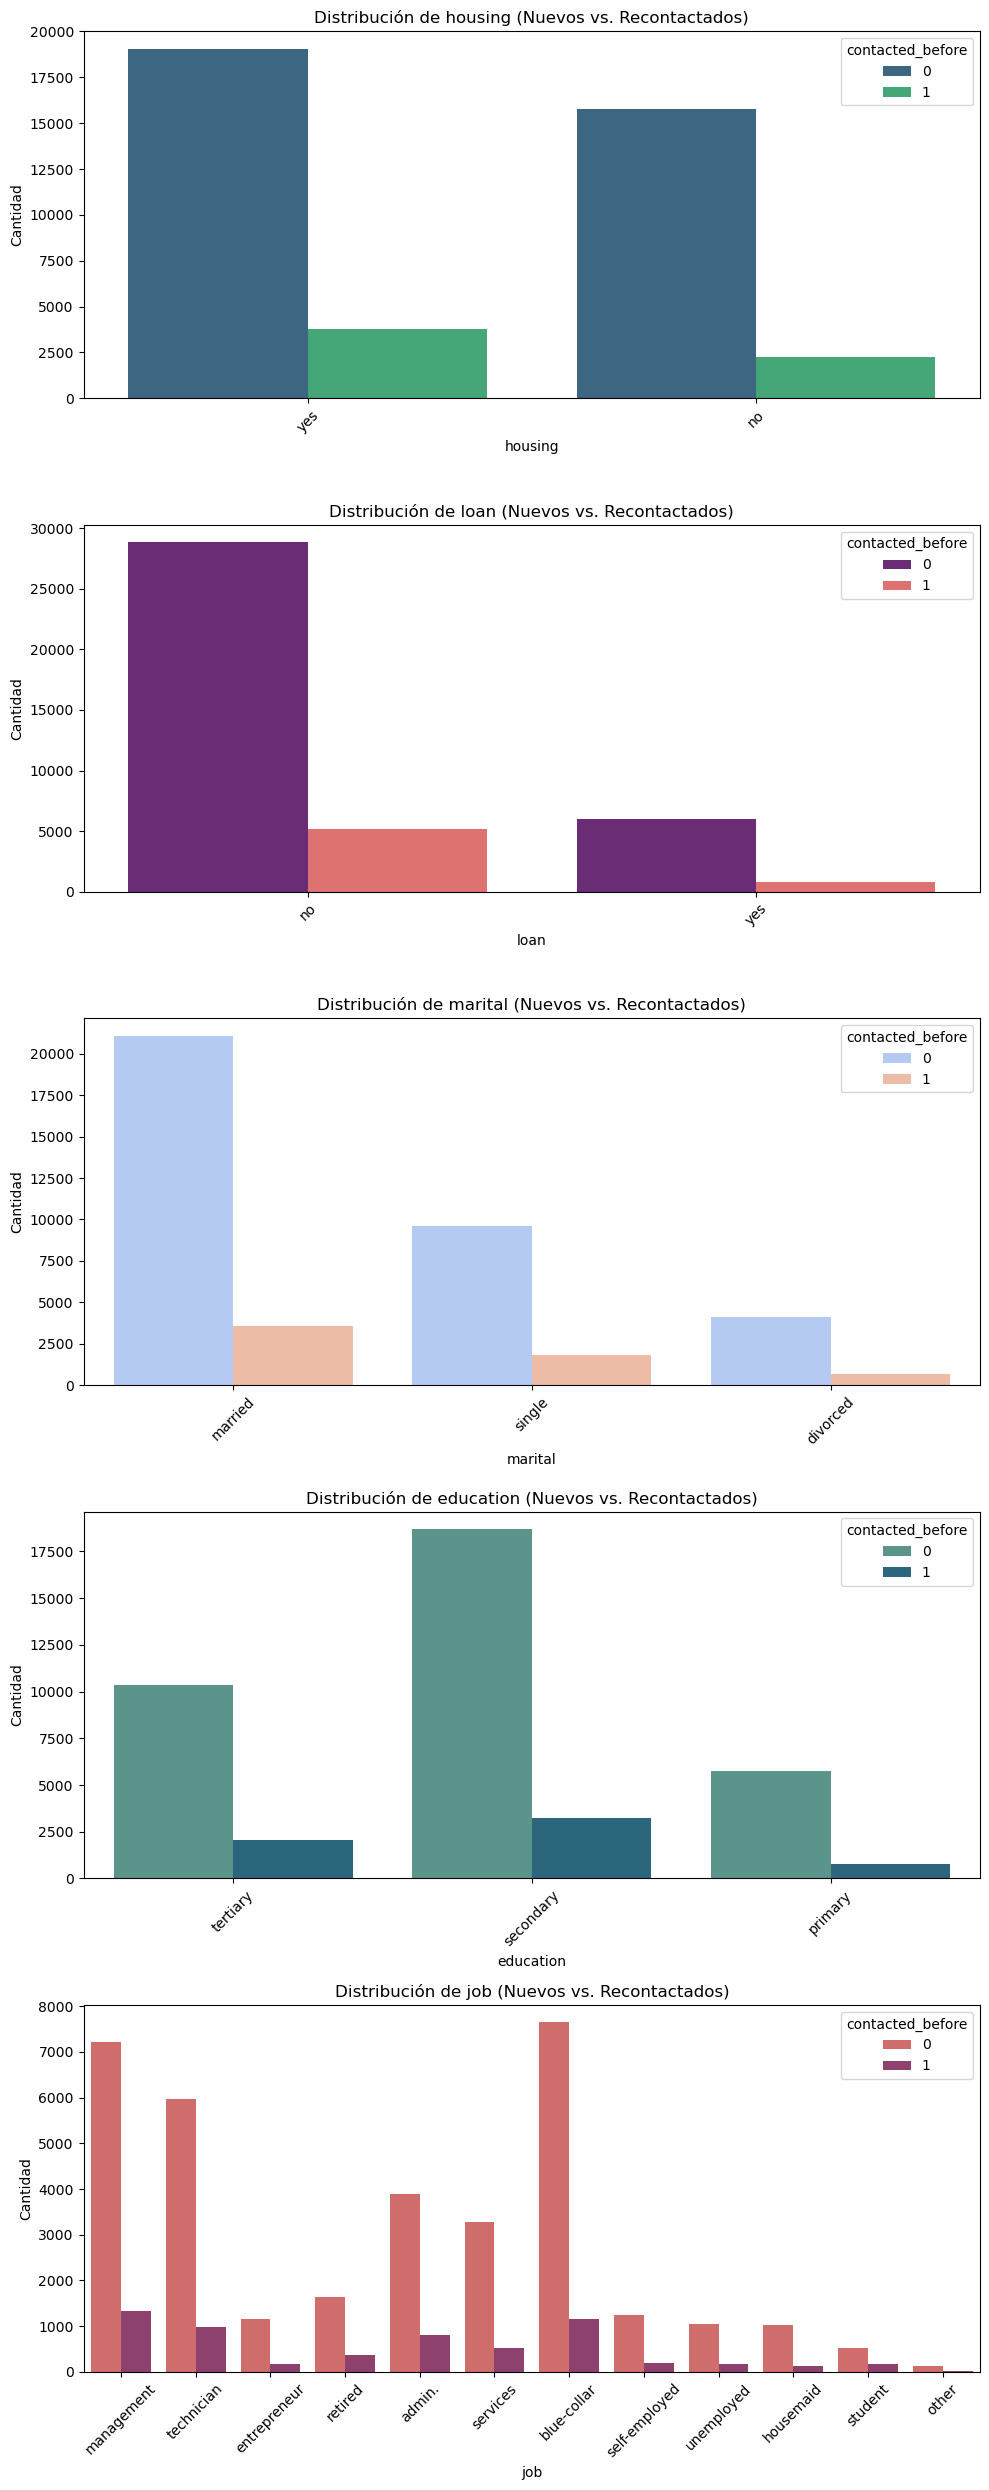

In [69]:
# Definir las variables categóricas que queremos analizar
categorical_vars = ["housing", "loan", "marital", "education", "job"]

# Definir una lista de paletas de colores diferentes para cada gráfico
palettes = ["viridis", "magma", "coolwarm", "crest", "flare", "pastel", "Set2", "chroma"]

# Configurar el tamaño de la figura con un gráfico por fila
fig, axes = plt.subplots(len(categorical_vars), 1, figsize=(10, 5 * len(categorical_vars)))

# Generar los gráficos uno debajo del otro
for i, var in enumerate(categorical_vars):
    sns.countplot(x=var, hue="contacted_before", data=df, palette=palettes[i], ax=axes[i])
    axes[i].set_title(f"Distribución de {var} (Nuevos vs. Recontactados)")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Cantidad")
    axes[i].tick_params(axis='x', rotation=45)  # Rotar etiquetas para mejor visualización

# Ajustar diseño y mostrar los gráficos
plt.tight_layout()
plt.show()

C:\Users\emc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


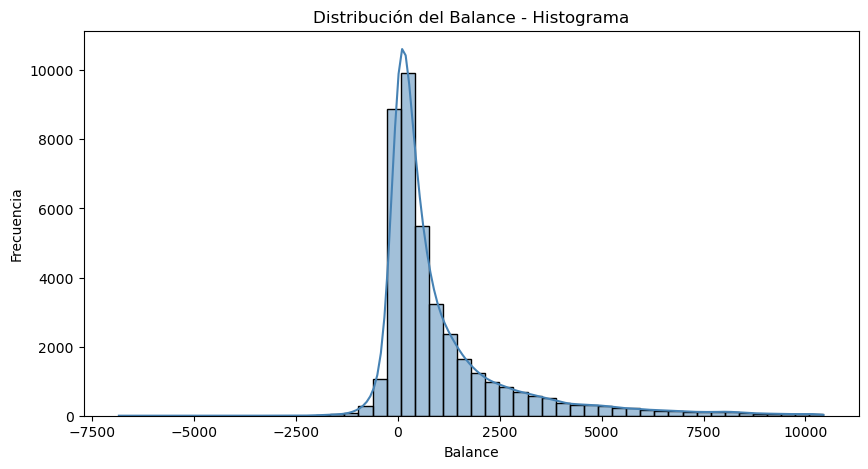

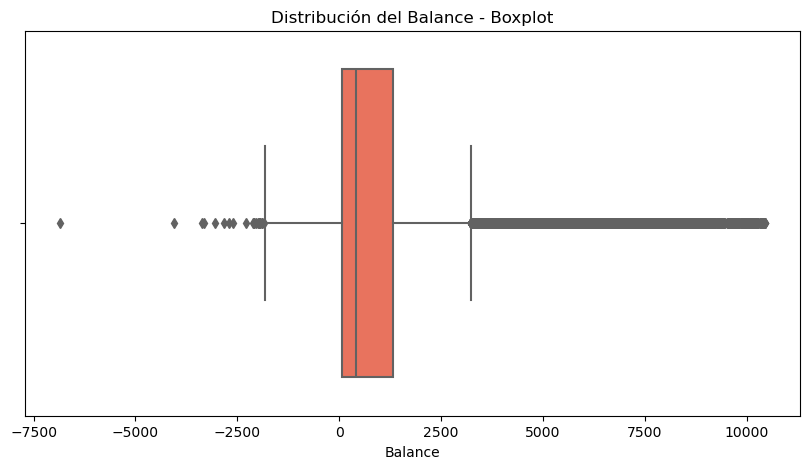

In [73]:
#  Histograma de balance
plt.figure(figsize=(10, 5))
sns.histplot(df["balance"], bins=50, kde=True, color="steelblue")
plt.title("Distribución del Balance - Histograma")
plt.xlabel("Balance")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot de balance
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["balance"], color="tomato")
plt.title("Distribución del Balance - Boxplot")
plt.xlabel("Balance")
plt.show()

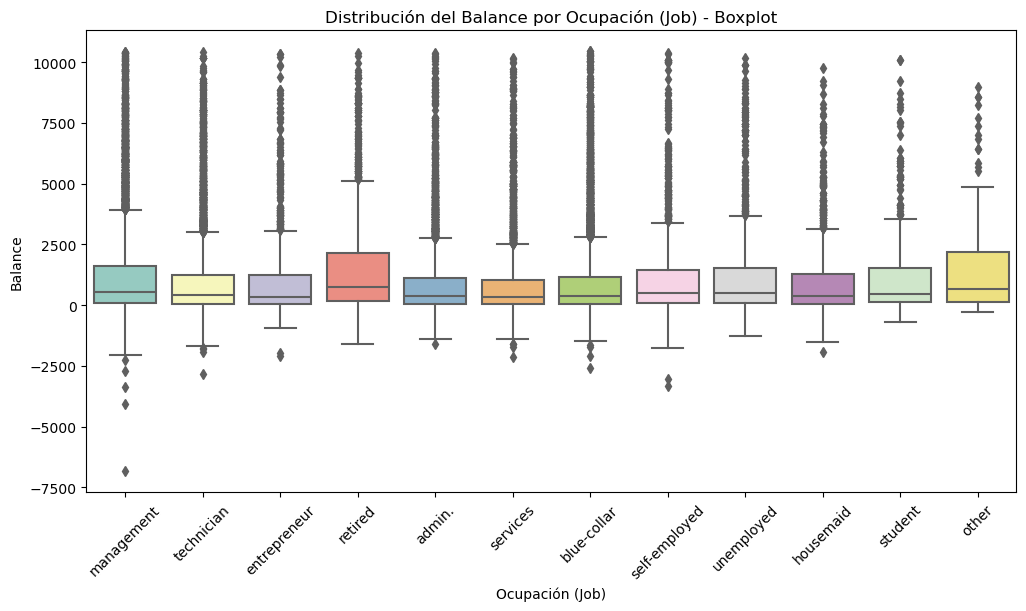

In [75]:
# Boxplot de balance por ocupación (job)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="job", y="balance", palette="Set3")
plt.title("Distribución del Balance por Ocupación (Job) - Boxplot")
plt.xlabel("Ocupación (Job)")
plt.ylabel("Balance")
plt.xticks(rotation=45)  # Rotar etiquetas para mejor lectura
plt.show()

## 5 - Profile the customers with higher likelihood of conversion and compare it with current bank targeting.

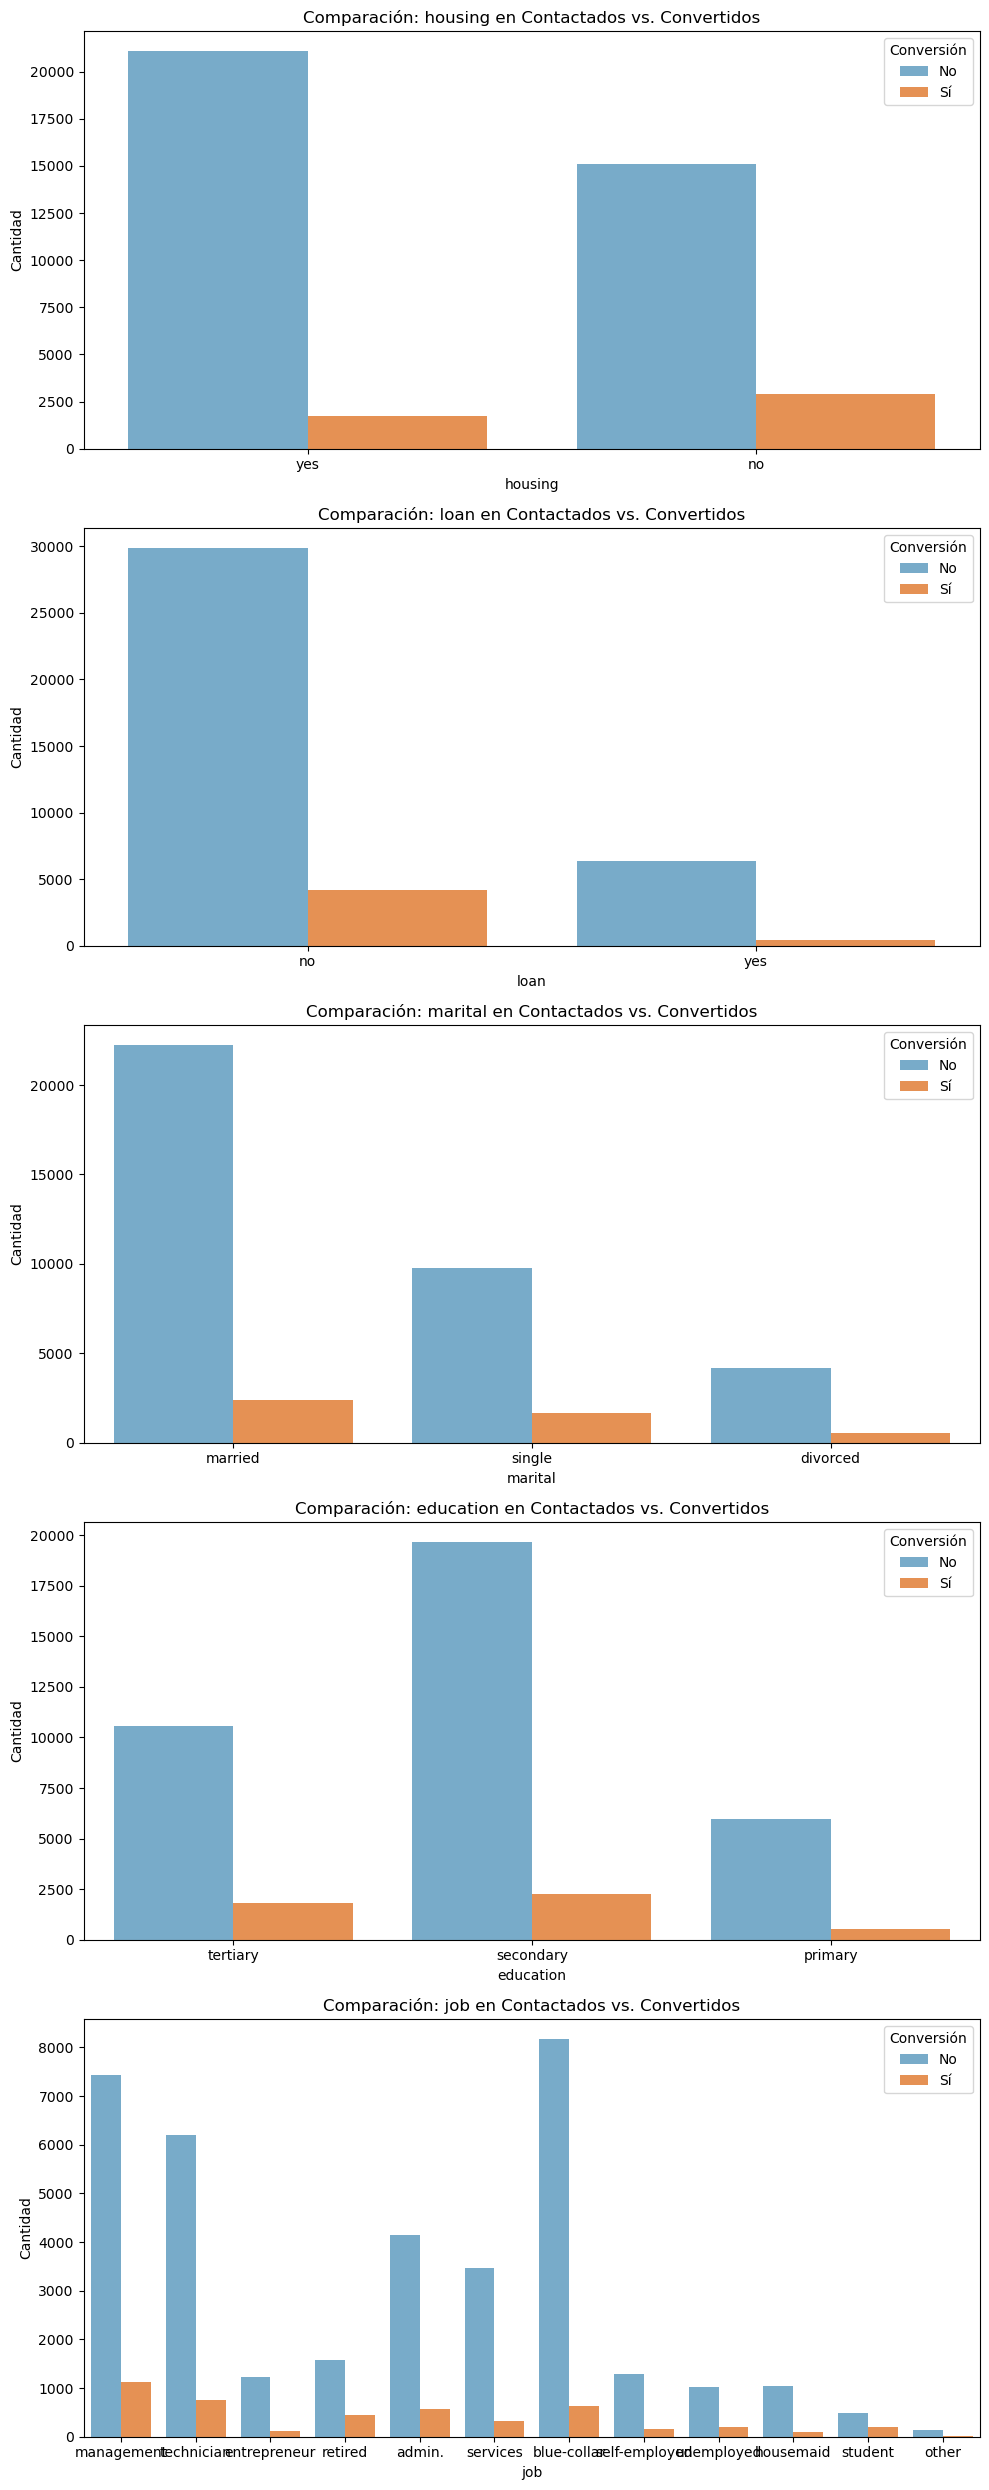

In [81]:
# Variables categóricas a analizar
categorical_vars = ["housing", "loan", "marital", "education", "job"]

# Configurar el tamaño de la figura con un gráfico por fila
fig, axes = plt.subplots(len(categorical_vars), 1, figsize=(10, 5 * len(categorical_vars)))

# Definir colores más claros y fáciles de diferenciar
colors = ["#6baed6", "#fd8d3c"]  # Azul suave (No) y Naranja suave (Sí)

# Generar los gráficos correctamente usando `hue="response_binary"`
for i, var in enumerate(categorical_vars):
    sns.countplot(x=var, hue="response", data=df, palette=colors, ax=axes[i])
    
    axes[i].set_title(f"Comparación: {var} en Contactados vs. Convertidos")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Cantidad")
    axes[i].legend(title="Conversión", labels=["No", "Sí"])

# Ajustar diseño y mostrar los gráficos
plt.tight_layout()
plt.show()


In [72]:
# Definir las variables categóricas a analizar
categorical_vars = ["housing", "loan", "marital", "education", "job"]

# Crear diccionario para almacenar los resultados
conversion_tables = {}

for var in categorical_vars:
    if var in df.columns:  # Verificar que la columna existe en df
        table = df.groupby(var)["response_binary"].value_counts(normalize=True).unstack() * 100  # Convertir a porcentaje
        table.columns = ["No (%)", "Sí (%)"]  # Renombrar columnas
        table = table[["Sí (%)", "No (%)"]]  # Reordenar columnas para que "Sí (%)" salga primero
        table = table.sort_values(by="Sí (%)", ascending=False)  # Ordenar por "Sí (%)" de mayor a menor
        conversion_tables[var] = table

# Mostrar los resultados
for var, table in conversion_tables.items():
    print(f"\nPorcentaje de Conversión por {var} (Ordenado por Sí %)")
    print(table)


Porcentaje de Conversión por housing (Ordenado por Sí %)
            Sí (%)     No (%)
housing                      
no       16.103435  83.896565
yes       7.611744  92.388256

Porcentaje de Conversión por loan (Ordenado por Sí %)
         Sí (%)     No (%)
loan                      
no    12.293637  87.706363
yes    6.677453  93.322547

Porcentaje de Conversión por marital (Ordenado por Sí %)
             Sí (%)     No (%)
marital                       
single    14.629031  85.370969
divorced  11.603952  88.396048
married    9.792622  90.207378

Porcentaje de Conversión por education (Ordenado por Sí %)
              Sí (%)     No (%)
education                      
tertiary   14.644588  85.355412
secondary  10.390735  89.609265
primary     8.379289  91.620711

Porcentaje de Conversión por job (Ordenado por Sí %)
                  Sí (%)     No (%)
job                                
student        29.462990  70.537010
retired        22.178218  77.821782
unemployed     15.676568  84

## 4.- Argue if the bank telemarketing strategy is appropriate. 